<!-- 1. Phân vùng theo histogram
Phương pháp Otsu -->

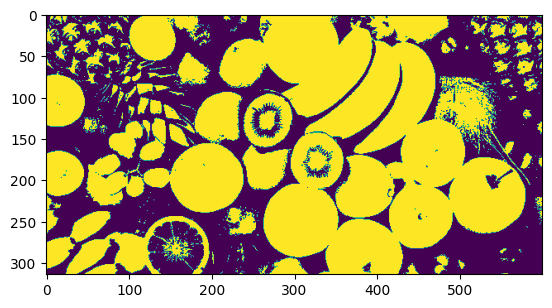

In [2]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu

data = Image.open('fruit.png').convert('L')
a = np.asarray(data)

# performing Otsu's thresholding
thres = threshold_otsu(a)

# pixels with intensity greater than the threshold are kept
b = a > thres

b = Image.fromarray((b * 255).astype(np.uint8))

plt.imshow(b)
plt.show()


<!-- Phương pháp adaptive Thresholding -->

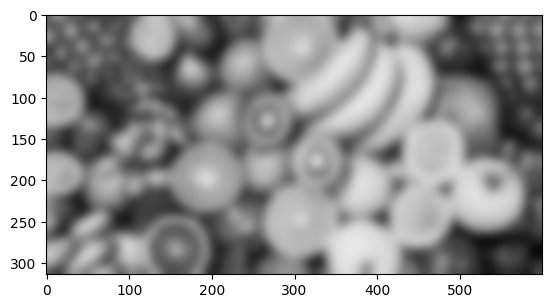

In [6]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters import threshold_local

data = Image.open('fruit.png').convert('L')

a = np.asarray(data)

# performing local thresholding
b = threshold_local(a, 39, offset=10)

b = Image.fromarray(b)

plt.imshow(b)
plt.show()


<!-- 2.2 Phân vùng theo region -->

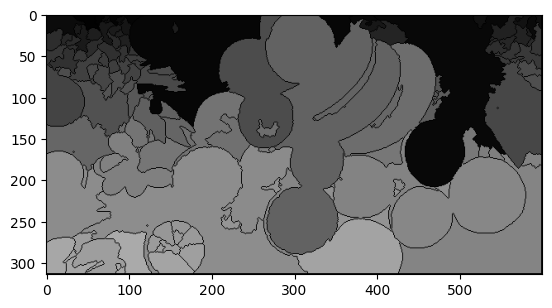

In [7]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = cv2.imread('fruit.png')

# converting image from color to grayscale
a = cv2.cvtColor(data, cv2.COLOR_BGR2GRAY)

# thresholding the image to obtain cell pixels
thresh, b1 = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# since Otsu’s method has over segmented the image, erosion operation is performed
b2 = cv2.erode(b1, None, iterations=2)

# distance transform is performed
dist_trans = cv2.distanceTransform(b2, 2, 3)

# thresholding the distance transform image to obtain pixels that are foreground
thresh, dt = cv2.threshold(dist_trans, 1, 255, cv2.THRESH_BINARY)

# performing labeling
labelled, ncc = label(dt)

# labelled is converted to 32-bit integer
labelled = labelled.astype(np.int32)

# performing watershed
cv2.watershed(data, labelled)
b = Image.fromarray(labelled)

plt.imshow(b)
plt.show()


<!-- 2.3 Biến đổi đối tượng trong ảnh -->

<!-- 2.3.1 Sử dụng binary_dilation -->

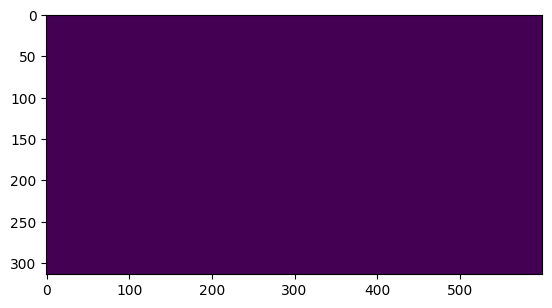

In [9]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('fruit.png').convert('L')

b = nd.binary_dilation(np.array(data), iterations=50)

c = Image.fromarray((b * 255).astype(np.uint8))
c.show()
plt.imshow(c)
plt.show()


<!-- 2.3.2 sử dụng binary_opening -->

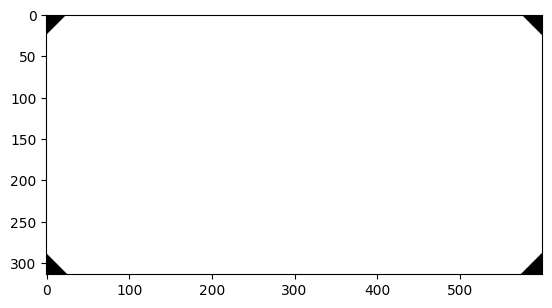

In [10]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('fruit.png').convert('L')

# defining the structuring element
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]

b = nd.binary_opening(data, structure=s, iterations=25)

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()


<!-- 2.3.3 Sử dụng binary_erosion -->

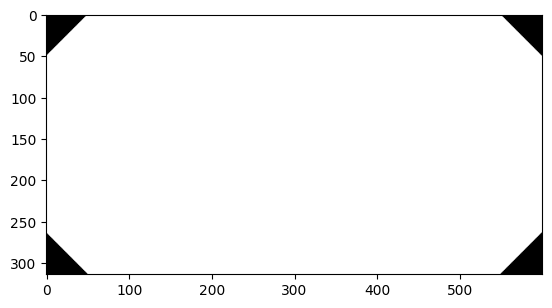

In [ ]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('fruit.png').convert('L')

# defining the structuring element
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]

b = nd.binary_erosion(data, structure=s, iterations=50)

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()


<!-- 2.3.4 Sử dụng binary_closing -->

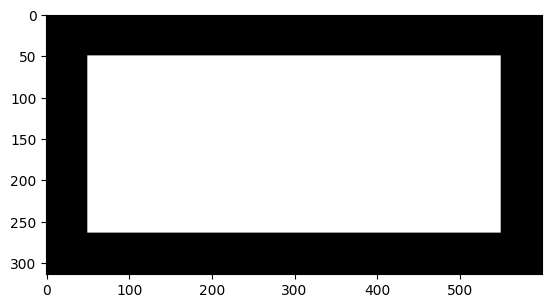

In [12]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('fruit.png').convert('L')

# defining the structuring element
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]

b = nd.binary_closing(data, structure=s, iterations=50)

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()


<!-- 1. Viết chương trình chọn Langbiang trong ảnh Đà lạt từ thư mục exercise. Tịnh tiến vùng chọn sang phải 100px. Sử dụng phương pháp otsu để
phân vùng Langbiang theo ngưỡng 0.3.Lưu vào máy tên Langbiang.jpg và hiển thị trên màn hình -->

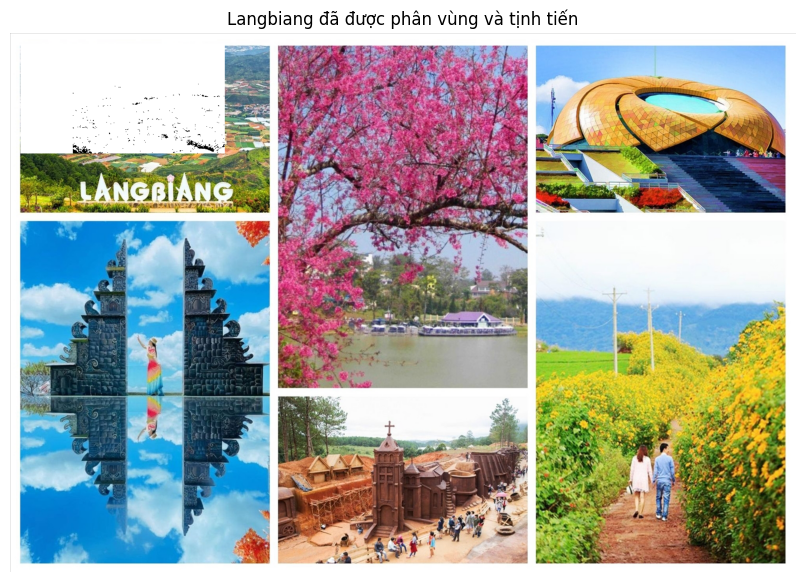

'exercise/Langbiang.jpg'

In [13]:
# Sau khi reset kernel, cần load lại thư viện và xử lý lại
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load lại ảnh "dalat.jpg"
image_path = "exercise/dalat.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Vùng chứa Langbiang (góc trên trái)
y1, y2 = 20, 230
x1, x2 = 20, 310
roi = image_gray[y1:y2, x1:x2]

# Áp dụng threshold ngưỡng 0.3
threshold = int(0.3 * 255)
_, binary = cv2.threshold(roi, threshold, 255, cv2.THRESH_BINARY)

# Tịnh tiến vùng Langbiang sang phải 100px
image_result = image_rgb.copy()
image_result[y1:y2, x1:x2] = 255  # Xóa vùng cũ

# Chèn ảnh đã phân vùng vào vị trí mới
new_x1 = x1 + 100
new_x2 = new_x1 + binary.shape[1]
binary_rgb = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
image_result[y1:y2, new_x1:new_x2] = binary_rgb

# Lưu ảnh kết quả
output_path = "exercise/Langbiang.jpg"
cv2.imwrite(output_path, cv2.cvtColor(image_result, cv2.COLOR_RGB2BGR))

# Hiển thị ảnh kết quả
plt.figure(figsize=(12, 7))
plt.imshow(image_result)
plt.title("Langbiang đã được phân vùng và tịnh tiến")
plt.axis("off")
plt.show()

output_path


<!-- 2 Viết chương trình chọn Hồ Xuân Hương trong ảnh Đà lạt từ thư mục Excercise. Xoay đối tượng vừa chọn 1 góc 45 độ
và dùng phương pháp adaptive thresholding với ngưỡng 60 và lưu vào máy tên là ho_xuan_huong.jpg -->

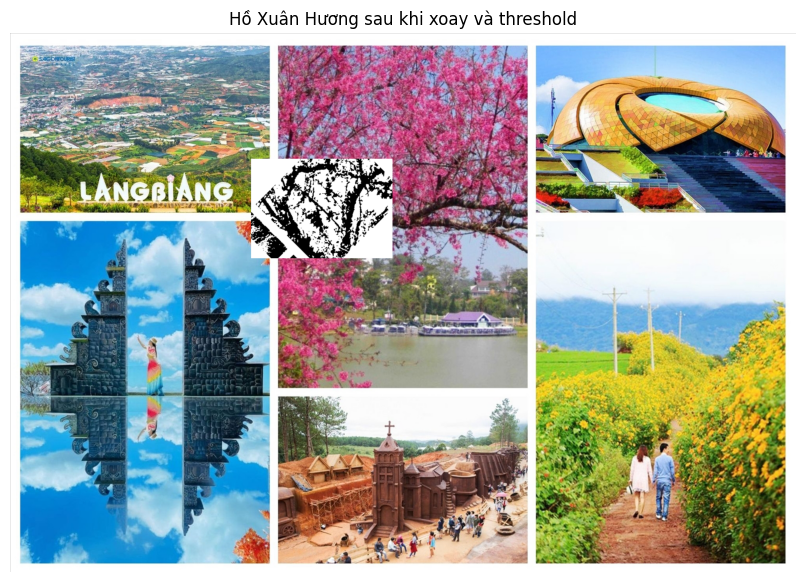

'exercise/ho_xuan_huong.jpg'

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load ảnh Đà Lạt
image_path = "exercise/dalat.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Xác định vùng Hồ Xuân Hương (theo hình: ở giữa bên phải, dưới cây hoa anh đào)
# Tọa độ ước lượng: x 460–730, y 240–430
y1, y2 = 240, 430
x1, x2 = 460, 730
roi = image_gray[y1:y2, x1:x2]

# Áp dụng adaptive thresholding với ngưỡng cục bộ (block size 61, C = 10)
adaptive = cv2.adaptiveThreshold(roi, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                 cv2.THRESH_BINARY, 61, 10)

# Xoay ảnh vùng chọn 45 độ
(h, w) = adaptive.shape
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(adaptive, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=255)

# Dán trở lại ảnh gốc
image_result = image_rgb.copy()
# Tô trắng vùng cũ
image_result[y1:y2, x1:x2] = 255

# Chèn ảnh xoay vào lại vị trí cũ
rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_GRAY2RGB)
image_result[y1:y2, x1:x2] = rotated_rgb

# Lưu kết quả
output_path = "exercise/ho_xuan_huong.jpg"
cv2.imwrite(output_path, cv2.cvtColor(image_result, cv2.COLOR_RGB2BGR))

# Hiển thị kết quả
plt.figure(figsize=(12, 7))
plt.imshow(image_result)
plt.title("Hồ Xuân Hương sau khi xoay và threshold")
plt.axis("off")
plt.show()

output_path


<!-- 3 Viết chương trình chọn quảng trường lâm viên trong ảnh đà lạt thư mục exercise. Dùng phương pháp coordinate mapping và binary closing cho vùng vừa chọn. Lưu vào máy với tên quang_truong_lam_vien.jpg -->

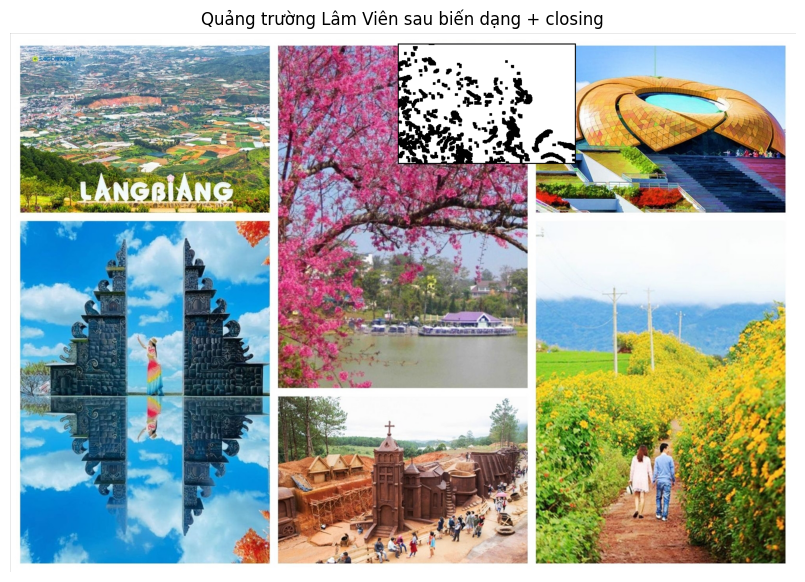

'exercise/quang_truong_lam_vien.jpg'

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import scipy.ndimage as nd

# Load ảnh Đà Lạt
image_path = "exercise/dalat.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Chọn vùng quảng trường Lâm Viên (góc trên bên phải ảnh)
x1, x2 = 740, 1080
y1, y2 = 20, 250
roi = image_gray[y1:y2, x1:x2]

# Bước 1: Coordinate mapping (biến dạng lượn sóng ảnh)
rows, cols = roi.shape
x, y = np.meshgrid(np.arange(cols), np.arange(rows))
wave_x = x + 10 * np.sin(2 * np.pi * y / 60)
wave_y = y + 10 * np.sin(2 * np.pi * x / 90)
coords = [wave_y, wave_x]
warped = nd.map_coordinates(roi, coords, order=1, mode='reflect')

# Bước 2: Binary closing (đóng nhị phân)
# Chuẩn hóa về nhị phân trước
_, binary = cv2.threshold(warped.astype(np.uint8), 127, 255, cv2.THRESH_BINARY)
closed = nd.binary_closing(binary, structure=np.ones((5, 5))).astype(np.uint8) * 255

# Dán lại vào ảnh gốc
roi_rgb = cv2.cvtColor(closed, cv2.COLOR_GRAY2RGB)
image_result = image_rgb.copy()
image_result[y1:y2, x1:x2] = roi_rgb

# Lưu ảnh kết quả
output_path = "exercise/quang_truong_lam_vien.jpg"
cv2.imwrite(output_path, cv2.cvtColor(image_result, cv2.COLOR_RGB2BGR))

# Hiển thị ảnh
plt.figure(figsize=(12, 7))
plt.imshow(image_result)
plt.title("Quảng trường Lâm Viên sau biến dạng + closing")
plt.axis("off")
plt.show()

output_path


<!-- 4 Tạo menu như hình
Viết chương trình cho phép người dùng nhập chức năng xử lý. ( Có thể chọn 1 chức năng duy nhất hoặc kết hợp 2 chức năng geometric_transformation và segment -->

In [ ]:
import cv2
import numpy as np

def coordinate_mapping(image):
    return cv2.resize(image, (image.shape[1], image.shape[0]))  # giữ nguyên để demo

def rotate(image, angle=45):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, matrix, (w, h))

def scale(image, fx=1.5, fy=1.5):
    return cv2.resize(image, None, fx=fx, fy=fy)

def shift(image, dx=100, dy=0):
    matrix = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(image, matrix, (image.shape[1], image.shape[0]))

def adaptive_thresholding(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                 cv2.THRESH_BINARY, 11, 2)

def binary_dilation(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5,5), np.uint8)
    return cv2.dilate(binary, kernel)

def binary_erosion(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5,5), np.uint8)
    return cv2.erode(binary, kernel)

def otsu(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, result = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return result

# Map chức năng
geo_funcs = {
    "coordinate_mapping": coordinate_mapping,
    "rotate": rotate,
    "scale": scale,
    "shift": shift
}

seg_funcs = {
    "adaptive_thresholding": adaptive_thresholding,
    "binary_dilation": binary_dilation,
    "binary_erosion": binary_erosion,
    "otsu": otsu
}

# Menu
print("Chọn 1 hoặc 2 chức năng:")
print("Geometric transformation:", list(geo_funcs.keys()))
print("Segmentation:", list(seg_funcs.keys()))

# Input
geo_choice = input("Chọn 1 chức năng geometric_transformation (Enter để bỏ qua): ")
seg_choice = input("Chọn 1 chức năng segment (Enter để bỏ qua): ")

# Đọc ảnh
image = cv2.imread("exercise/dalat.jpg")
if image is None:
    print("Không tìm thấy ảnh.")
    exit()

result = image.copy()

# Áp dụng transformation nếu có
if geo_choice in geo_funcs:
    result = geo_funcs[geo_choice](result)

# Áp dụng segmentation nếu có
if seg_choice in seg_funcs:
    result = seg_funcs[seg_choice](result)

# Hiển thị kết quả
cv2.imshow("Kết quả", result)
cv2.waitKey(0)
cv2.destroyAllWindows()
